# Problem Statement: Medical Insurence Premium

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
data = pd.read_csv('/Users/vydhyamvishnusai/MEDICAL_INSURANCE_PREMIUM/insurance.csv')

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
data.shape

(1338, 7)

In [8]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(1)

# EDA

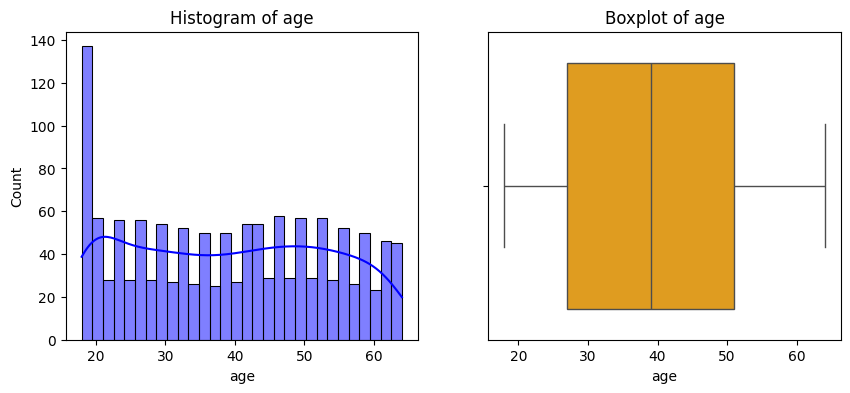

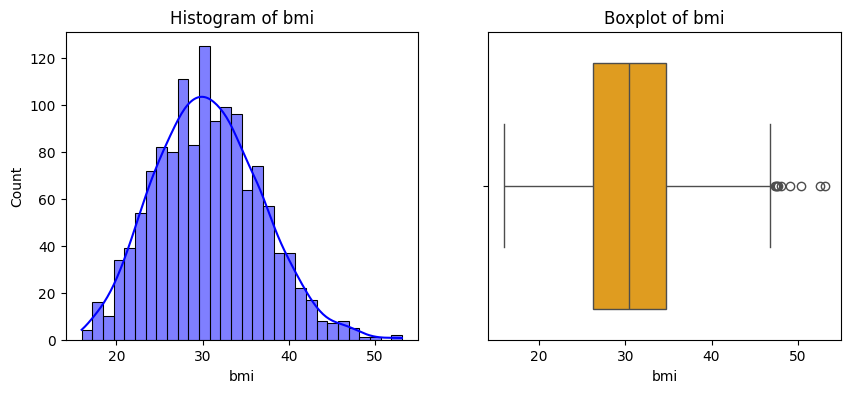

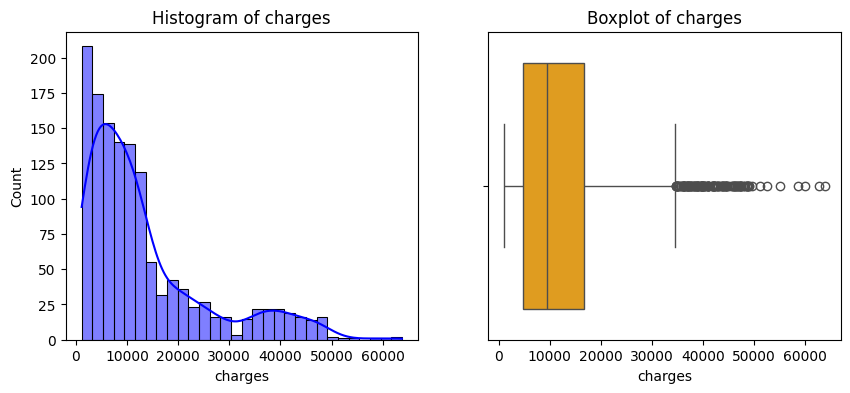

In [10]:
numeric_features = ['age', 'bmi', 'charges']
for feature in numeric_features:
    plt.figure(figsize = (10,4))
    #Histogram
    plt.subplot(1,2,1)
    sns.histplot(data[feature], kde = True, bins = 30, color = 'blue')
    plt.title(f'Histogram of {feature}')

    #Boxplot 
    plt.subplot(1,2,2)
    sns.boxplot(x = data[feature], color = 'orange')
    plt.title(f'Boxplot of {feature}')
    plt.show()

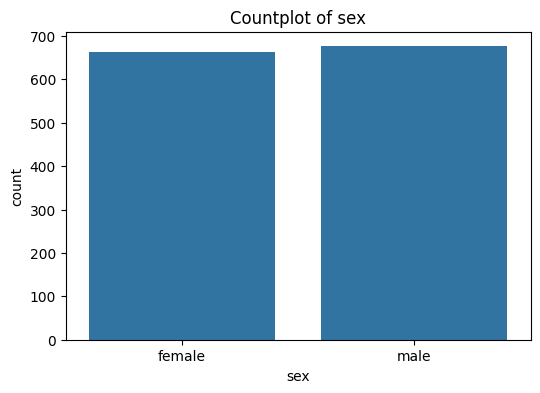

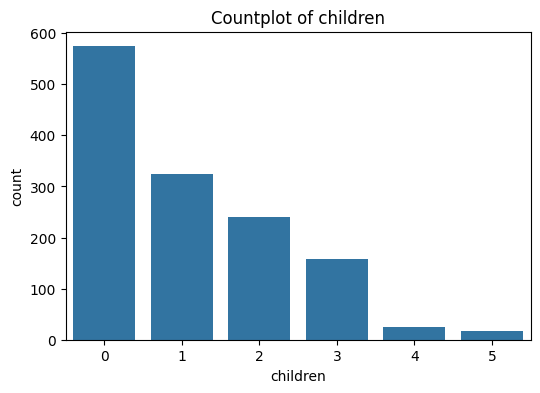

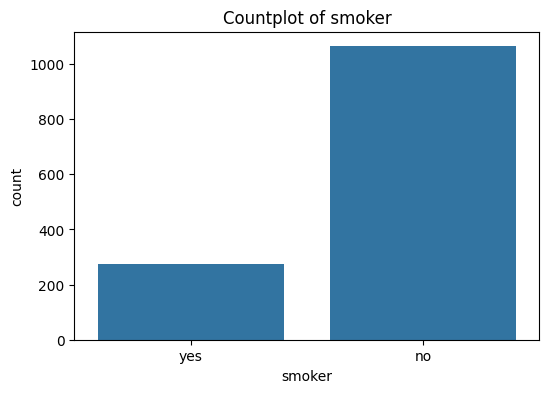

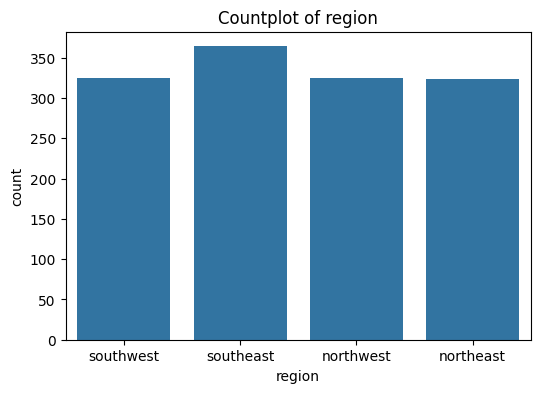

In [11]:
categorical_features = ['sex', 'children', 'smoker' , 'region']
for figure in categorical_features:
    plt.figure(figsize = (6,4))
    sns.countplot(data = data, x = figure )
    plt.title(f'Countplot of {figure}')
    plt.show()

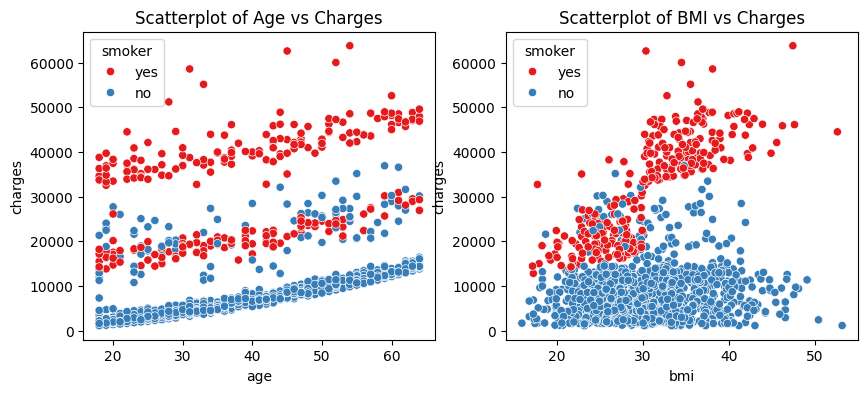

In [12]:
plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
sns.scatterplot(data = data, x = 'age', y = 'charges', hue = 'smoker', palette = 'Set1')
plt.title(f'Scatterplot of Age vs Charges')
plt.subplot(1,2,2)
sns.scatterplot(data = data, x = 'bmi', y = 'charges', hue = 'smoker', palette = 'Set1')
plt.title(f'Scatterplot of BMI vs Charges')
plt.show()



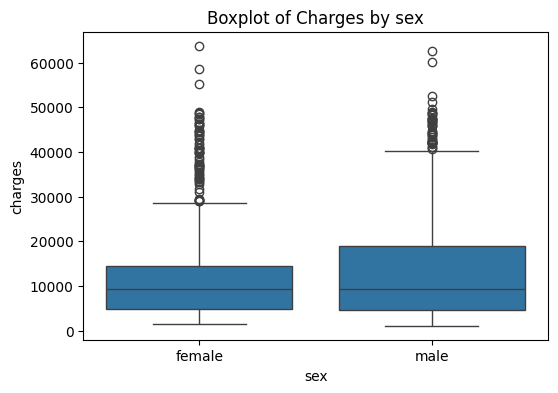

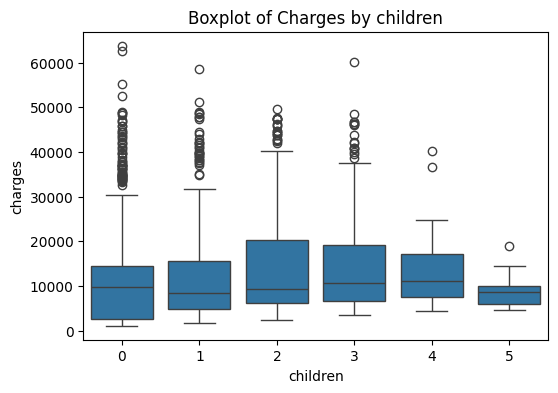

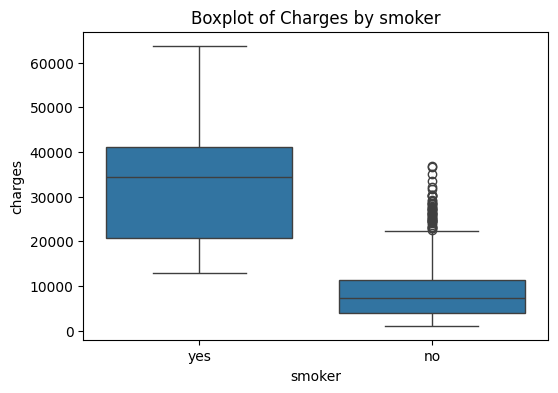

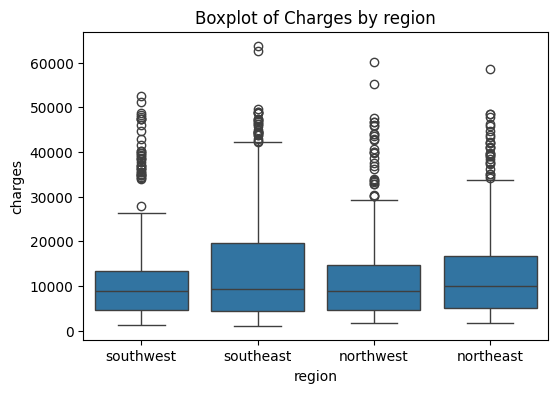

In [13]:
categorical_features = ['sex', 'children', 'smoker', 'region']
for feature in categorical_features:
    plt.figure(figsize = (6,4))
    sns.boxplot(data = data, x = feature, y = 'charges')
    plt.title(f'Boxplot of Charges by {feature}')
    plt.show()

## One hot encoding

In [14]:
from sklearn.preprocessing import OneHotEncoder

In [15]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [16]:
encoded_df =  pd.get_dummies(data,columns = ['sex', 'smoker', 'region'], drop_first = True).astype(int)
encoded_df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


In [17]:
x = encoded_df.drop(['charges'], axis = 1)
y = encoded_df['charges']

In [18]:
x

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,0,1,0,0,1
1,18,33,1,1,0,0,1,0
2,28,33,3,1,0,0,1,0
3,33,22,0,1,0,1,0,0
4,32,28,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,30,3,1,0,1,0,0
1334,18,31,0,0,0,0,0,0
1335,18,36,0,0,0,0,1,0
1336,21,25,0,0,0,0,0,1


In [19]:
y

0       16884
1        1725
2        4449
3       21984
4        3866
        ...  
1333    10600
1334     2205
1335     1629
1336     2007
1337    29141
Name: charges, Length: 1338, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [21]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 8)
(268, 8)
(1070,)
(268,)


## Building Multiple Linear Regression Model

In [22]:
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error 

lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred = lr.predict(x_test)


In [24]:
lr.coef_

array([ 2.57096202e+02,  3.35633616e+02,  4.27589784e+02, -1.72621748e+01,
        2.36556741e+04, -3.64205361e+02, -6.67644378e+02, -8.19619053e+02])

In [25]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error {mse}')

Mean Squared Error 33566439.73530042


In [26]:
encoded_df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


# Improving the model

In [27]:
encoded_df['charges'] = np.log(encoded_df['charges'])
encoded_df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,9.734122,0,1,0,0,1
1,18,33,1,7.452982,1,0,0,1,0
2,28,33,3,8.400435,1,0,0,1,0
3,33,22,0,9.998070,1,0,1,0,0
4,32,28,0,8.259976,1,0,1,0,0


In [28]:
x = encoded_df.drop(['charges'], axis = 1)
y = encoded_df['charges']

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [30]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
y_pred = lr.predict(x_test)


In [32]:
y_pred

array([ 9.11912015,  8.63756399, 11.09417094,  9.1154333 ,  9.54655723,
        8.68361266,  7.94649569,  9.61747471,  8.24293292,  9.25898673,
       10.03890426,  8.91961939,  8.39621517, 10.81806343, 10.99269899,
       10.70535447,  9.35059662, 10.65991337,  8.96488232, 10.3748996 ,
        8.48718898,  8.94843001,  7.91408642,  8.33662962,  9.36755637,
        9.33746125,  9.46069735,  8.60698325,  9.20122231,  7.86617603,
        9.06431414,  9.37043546,  8.09764821,  8.5601349 ,  8.24640301,
        9.05008437,  8.09506604,  8.88938878, 10.74851796, 10.19523344,
        8.42400214,  8.18989074,  9.41625275,  9.2830181 ,  8.63306085,
        9.33588616,  8.34971807,  8.38998879, 10.62010949,  8.6053592 ,
        9.56339114,  7.94513537,  9.01672892,  7.94850528,  9.22211515,
        9.3112575 ,  8.34591735, 10.27604821,  9.36499506,  9.31681036,
        9.50904989,  8.71342744,  9.71190828,  8.94658826,  9.24175896,
        8.38811469,  9.83680471,  9.25398848,  8.24456126,  8.13

In [33]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error {mse}')

Mean Squared Error 0.17538221423345823


<Axes: >

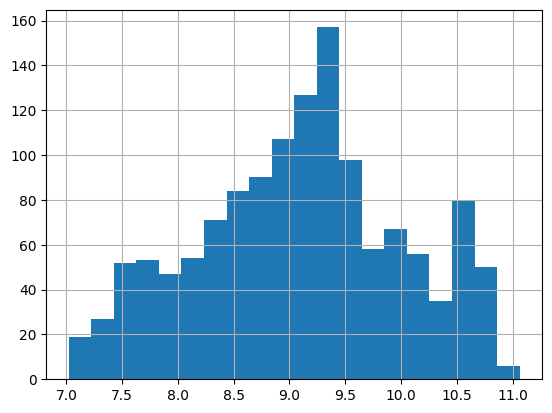

In [34]:
encoded_df['charges'].hist(bins = 20)

## Feature Imporatance: LOFO on Multi Linear Regression

In [ ]:
features_importance = {} 
for features in x.columns:
    x_train_reduced = x_train.drop(column = [features])
    x_test_reduced = x_test.drop(column = [features])
    lr.fit(x_train, y_train)
    